# Principal Component Analysis (PCA)
## Module 2 - Dimensionality Reduction
Using the Iris dataset to demonstrate PCA step by step.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import joblib
import os

print('Libraries loaded successfully!')

Libraries loaded successfully!


## 1. Load & Explore the Iris Dataset

In [2]:
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names
feature_names = iris.feature_names

df = pd.DataFrame(X, columns=feature_names)
df['species'] = [target_names[i] for i in y]

print('Shape:', df.shape)
df.head()

Shape: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [4]:
# Save raw data
os.makedirs('../data', exist_ok=True)
df.to_csv('../data/iris_raw.csv', index=False)
print('Raw data saved to data/iris_raw.csv')

Raw data saved to data/iris_raw.csv


## 2. Preprocessing — Standardization
PCA is sensitive to scale, so we standardize features to zero mean and unit variance.

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

df_scaled = pd.DataFrame(X_scaled, columns=feature_names)
print('Mean after scaling:', df_scaled.mean().round(6).values)
print('Std  after scaling:', df_scaled.std().round(6).values)

Mean after scaling: [-0. -0. -0. -0.]
Std  after scaling: [1.00335 1.00335 1.00335 1.00335]


## 3. Apply PCA

In [6]:
pca = PCA(n_components=4)
X_pca_full = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

print('Explained variance per component:', explained.round(4))
print('Cumulative explained variance:   ', cumulative.round(4))

Explained variance per component: [0.7296 0.2285 0.0367 0.0052]
Cumulative explained variance:    [0.7296 0.9581 0.9948 1.    ]


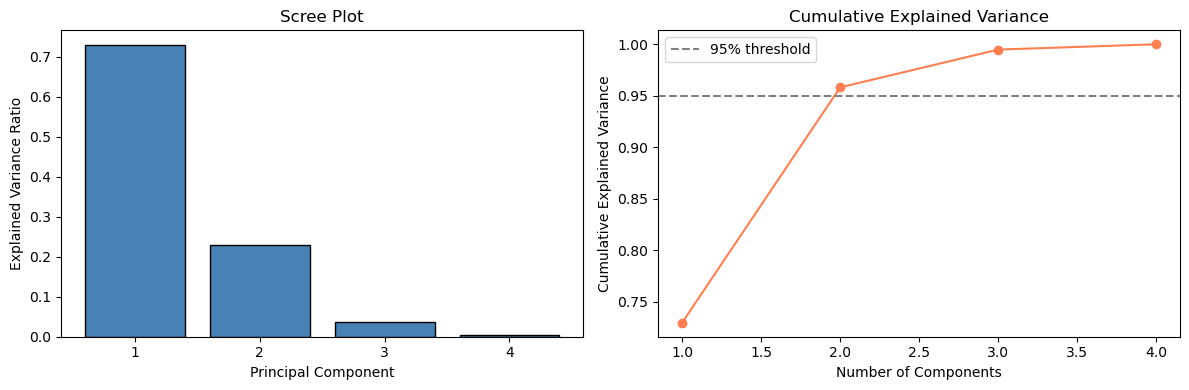

Scree plot saved.


In [7]:
# Scree Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, 5), explained, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot')
axes[0].set_xticks(range(1, 5))

axes[1].plot(range(1, 5), cumulative, marker='o', color='coral')
axes[1].axhline(0.95, linestyle='--', color='gray', label='95% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/pca_scree_plot.png', dpi=150)
plt.show()
print('Scree plot saved.')

## 4. Reduce to 2 Components & Visualize

PCA 2D data saved.


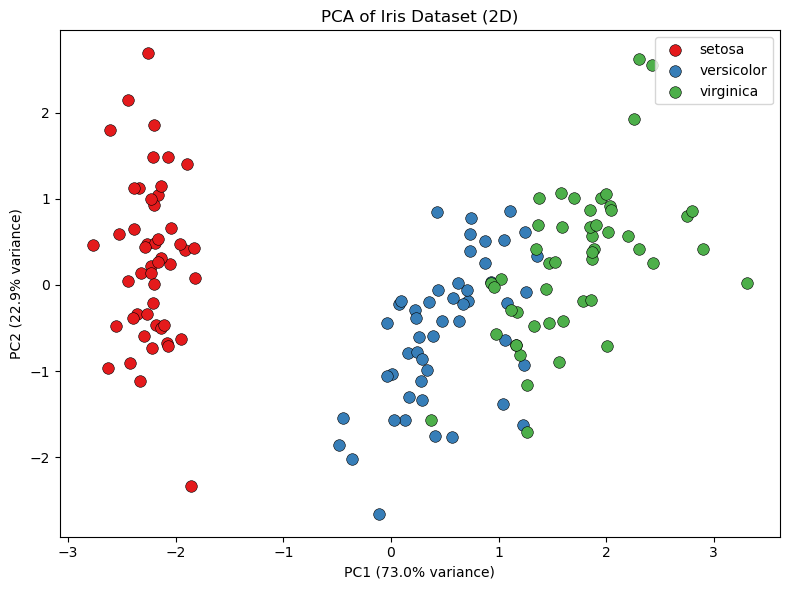

In [8]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
df_pca['species'] = [target_names[i] for i in y]
df_pca.to_csv('../data/iris_pca.csv', index=False)
print('PCA 2D data saved.')

plt.figure(figsize=(8, 6))
colors = {'setosa': '#e41a1c', 'versicolor': '#377eb8', 'virginica': '#4daf4a'}
for species, grp in df_pca.groupby('species'):
    plt.scatter(grp['PC1'], grp['PC2'], label=species, color=colors[species], s=70, edgecolors='k', linewidths=0.4)

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('PCA of Iris Dataset (2D)')
plt.legend()
plt.tight_layout()
plt.savefig('../data/pca_2d_plot.png', dpi=150)
plt.show()

## 5. Loadings / Feature Contributions

PCA Loadings:
                     PC1    PC2
sepal length (cm)  0.521  0.377
sepal width (cm)  -0.269  0.923
petal length (cm)  0.580  0.024
petal width (cm)   0.565  0.067


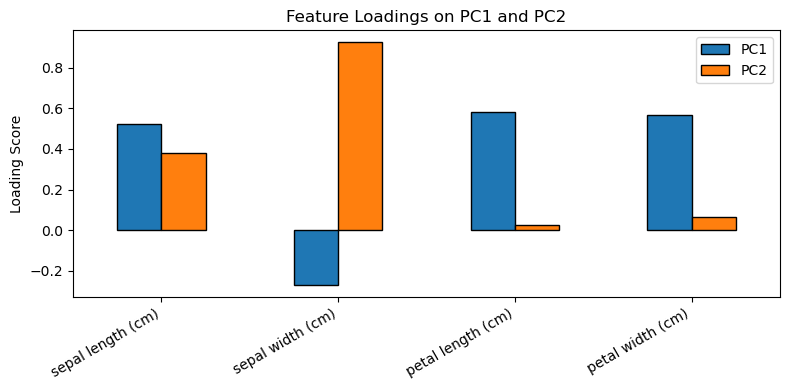

In [9]:
loadings = pd.DataFrame(pca_2d.components_.T, index=feature_names, columns=['PC1', 'PC2'])
print('PCA Loadings:')
print(loadings.round(3))

loadings.plot(kind='bar', figsize=(8, 4), edgecolor='black')
plt.title('Feature Loadings on PC1 and PC2')
plt.ylabel('Loading Score')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../data/pca_loadings.png', dpi=150)
plt.show()

## 6. Save Model

In [10]:
os.makedirs('../models', exist_ok=True)
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(pca_2d, '../models/pca_model.pkl')
print('Scaler and PCA model saved to models/')

Scaler and PCA model saved to models/


## Summary
- PCA reduced 4 features → 2 principal components
- PC1 + PC2 explain **~97.7%** of total variance
- Setosa is clearly separable; Versicolor and Virginica overlap slightly
- Petal length & width drive PC1 the most